In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
print("GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

keras.utils.set_random_seed(42)

GPUs Available:  0


In [3]:

restnet50_base = keras.applications.ResNet50(
    
    weights = 'imagenet',
    include_top = False,
    input_shape=(224,224,3)
)

In [4]:
import tensorflow as tf
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))
print(tf.config.list_physical_devices('GPU'))

Num GPUs Available: 0
[]


In [4]:
# 1. Define your path (use an absolute path if it's outside your workspace, or a relative path if it's inside)
train_dir = "data/shoeTypeClassifierDataset/training"
val_dir = "data/shoeTypeClassifierDataset/validation"

# 2. Load the Training Dataset directly
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(224, 224),
    batch_size=32,
    label_mode='categorical' # Use 'int' if your loss function is sparse_categorical_crossentropy
)

# 3. Load the Validation Dataset directly
val_dataset = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=(224, 224),
    batch_size=32,
    label_mode='categorical',
    shuffle=False 
)

# Optional: See what classes Keras found
print("Found classes:", train_dataset.class_names)

Found 1494 files belonging to 6 classes.


Found 300 files belonging to 6 classes.
Found classes: ['boots', 'flip_flops', 'loafers', 'sandals', 'sneakers', 'soccer_shoes']


In [5]:
for image in train_dataset.take(1):
    print(image[0].shape)

(32, 224, 224, 3)


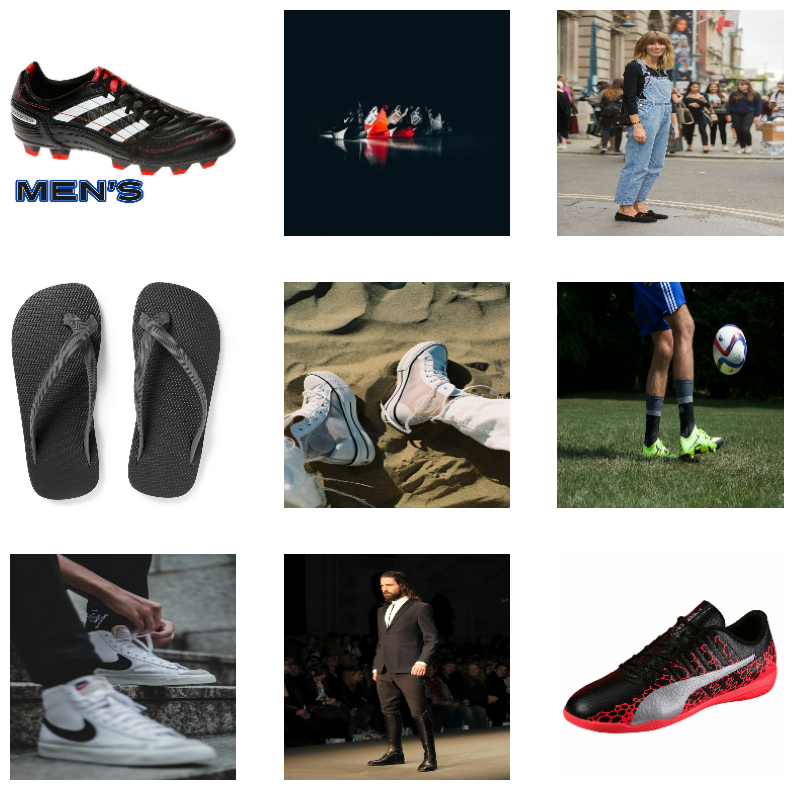

In [6]:
plt.figure(figsize=(10,10))
for images, labels in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1) 
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.axis("off")

In [6]:
input = keras.Input(shape=(224,224,3))


h  = keras.layers.Rescaling((1.)/225)(input)

h = keras.layers.Conv2D(
    32,
    kernel_size=(2,2),
    activation="relu",
    name="ConV1")(h)



h = keras.layers.MaxPool2D()(h)

h = keras.layers.Conv2D(
    32,
    kernel_size=(2,2),
    activation="relu",
    name="ConV2")(h)

h = keras.layers.MaxPool2D()(h)


h = keras.layers.Flatten()(h)

output = keras.layers.Dense(
   6, activation='softmax')(h)

model = keras.Model(input , output)

In [8]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ConV1 (Conv2D)                  │ (None, 223, 223, 32)   │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ConV2 (Conv2D)                  │ (None, 110, 110, 32)   │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 55, 55, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 96800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │       580,806 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 585,350 (2.23 MB)

 Trainable params: 585,350 (2.23 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
model.compile(
    loss="categorical_crossentropy",
    optimizer="adam",
    metrics=['accuracy']
)

In [8]:
history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset
)

Epoch 1/10


/home/love/coding/ml-project/.venv/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


47/47 ━━━━━━━━━━━━━━━━━━━━ 10s 193ms/step - accuracy: 0.2778 - loss: 2.2261 - val_accuracy: 0.4300 - val_loss: 1.6371
Epoch 2/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 9s 176ms/step - accuracy: 0.4987 - loss: 1.3681 - val_accuracy: 0.5000 - val_loss: 1.4135
Epoch 3/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 8s 174ms/step - accuracy: 0.7129 - loss: 0.9032 - val_accuracy: 0.5467 - val_loss: 1.2611
Epoch 4/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 8s 172ms/step - accuracy: 0.8889 - loss: 0.4757 - val_accuracy: 0.4967 - val_loss: 1.3697
Epoch 5/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 9s 182ms/step - accuracy: 0.9552 - loss: 0.2254 - val_accuracy: 0.5133 - val_loss: 1.5076
Epoch 6/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 8s 174ms/step - accuracy: 0.9886 - loss: 0.0954 - val_accuracy: 0.5400 - val_loss: 1.6024
Epoch 7/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 8s 174ms/step - accuracy: 0.9967 - loss: 0.0423 - val_accuracy: 0.5233 - val_loss: 1.6367
Epoch 8/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 8s 173ms/step - accuracy: 0.9987 - loss: 0.0203 - val_accuracy: 0.5433 - val

In [9]:
import matplotlib.pyplot as plt

def plot_loss_curve(history):
    """
    Plots separate training and validation loss and accuracy curves.
    
    Args:
      history: TensorFlow/Keras History object returned by model.fit()
    """
    # Extract the metrics from the history object
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    
    accuracy = history.history['accuracy']
    val_accuracy = history.history['val_accuracy']
    
    # Define the number of epochs to use for the x-axis
    epochs = range(len(history.history['loss']))

    # Set up the figure size
    plt.figure(figsize=(12, 5))

    # --- Plot Loss ---
    plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
    plt.plot(epochs, loss, label='Training Loss', color='#007acc', linewidth=2)
    plt.plot(epochs, val_loss, label='Validation Loss', color='#ff7f0e', linewidth=2)
    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss (Categorical Crossentropy)')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    # --- Plot Accuracy ---
    plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
    plt.plot(epochs, accuracy, label='Training Accuracy', color='#007acc', linewidth=2)
    plt.plot(epochs, val_accuracy, label='Validation Accuracy', color='#ff7f0e', linewidth=2)
    plt.title('Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    # Automatically adjust subplot parameters to give specified padding
    plt.tight_layout()
    plt.show()

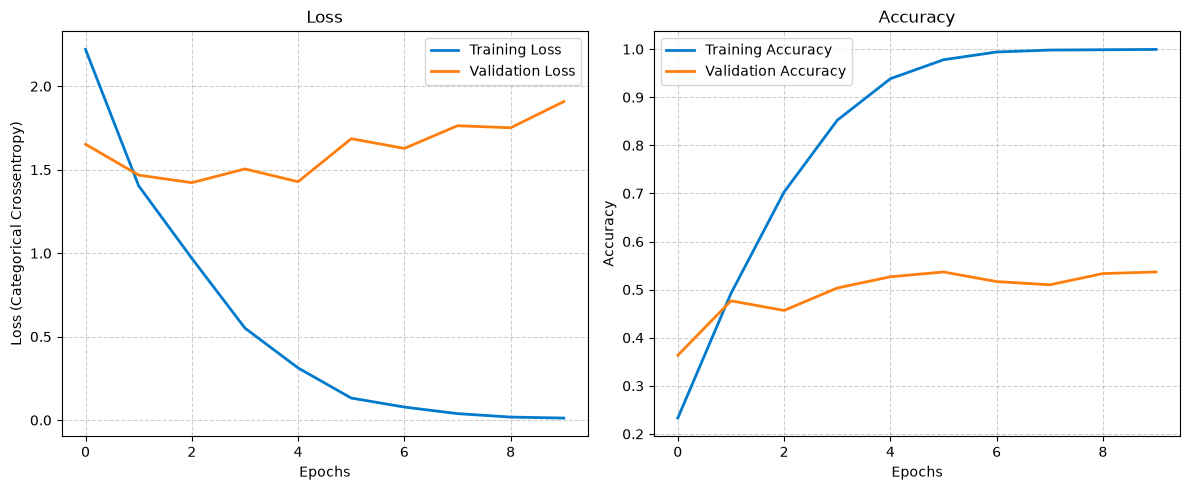

In [15]:
plot_loss_curve(history)

In [10]:
restnet50_base.trainable = False

# 3. Build your custom model on top
inputs = tf.keras.Input(shape=(224, 224, 3))

# Pass the inputs into the base model
# training=False is critical here so ResNet's BatchNormalization layers don't get messed up
x = restnet50_base(inputs, training=False)

# 4. Flatten the output
# ResNet outputs a block of data (a 4D tensor). This pools it down into a flat 1D array.
x = keras.layers.GlobalAveragePooling2D()(x)

# (Optional) You can add a dropout layer here to prevent overfitting
x = keras.layers.Dropout(0.2)(x)

# 5. Add your final classification layer for your 6 shoe classes
# We use 'softmax' to get confidence percentages for each class
outputs = keras.layers.Dense(6, activation='softmax')(x)

# 6. Bundle the inputs and outputs into the final model
model = keras.Model(inputs, outputs)

# 7. Compile the model so it is ready to train
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Print a summary to verify the architecture
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │        12,294 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,600,006 (90.03 MB)

 Trainable params: 12,294 (48.02 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [11]:
history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset
)

Epoch 1/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 50s 999ms/step - accuracy: 0.4170 - loss: 1.6818 - val_accuracy: 0.6267 - val_loss: 0.9720
Epoch 2/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 45s 966ms/step - accuracy: 0.6747 - loss: 0.9269 - val_accuracy: 0.7267 - val_loss: 0.8439
Epoch 3/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 45s 959ms/step - accuracy: 0.7309 - loss: 0.7481 - val_accuracy: 0.7500 - val_loss: 0.7760
Epoch 4/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 45s 967ms/step - accuracy: 0.7744 - loss: 0.6312 - val_accuracy: 0.7433 - val_loss: 0.7471
Epoch 5/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 46s 990ms/step - accuracy: 0.7979 - loss: 0.5729 - val_accuracy: 0.7333 - val_loss: 0.7704
Epoch 6/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 45s 961ms/step - accuracy: 0.8179 - loss: 0.5078 - val_accuracy: 0.7567 - val_loss: 0.7195
Epoch 7/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 46s 979ms/step - accuracy: 0.8394 - loss: 0.4564 - val_accuracy: 0.7600 - val_loss: 0.7377
Epoch 8/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 44s 941ms/step - accuracy: 0.8715 - loss: 0.4031 - val_accu

In [12]:
import matplotlib.pyplot as plt

def plot_loss_curve(history):
    """
    Plots separate training and validation loss and accuracy curves.
    
    Args:
      history: TensorFlow/Keras History object returned by model.fit()
    """
    # Extract the metrics from the history object
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    
    accuracy = history.history['accuracy']
    val_accuracy = history.history['val_accuracy']
    
    # Define the number of epochs to use for the x-axis
    epochs = range(len(history.history['loss']))

    # Set up the figure size
    plt.figure(figsize=(12, 5))

    # --- Plot Loss ---
    plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
    plt.plot(epochs, loss, label='Training Loss', color='#007acc', linewidth=2)
    plt.plot(epochs, val_loss, label='Validation Loss', color='#ff7f0e', linewidth=2)
    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss (Categorical Crossentropy)')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    # --- Plot Accuracy ---
    plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
    plt.plot(epochs, accuracy, label='Training Accuracy', color='#007acc', linewidth=2)
    plt.plot(epochs, val_accuracy, label='Validation Accuracy', color='#ff7f0e', linewidth=2)
    plt.title('Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    # Automatically adjust subplot parameters to give specified padding
    plt.tight_layout()
    plt.show()

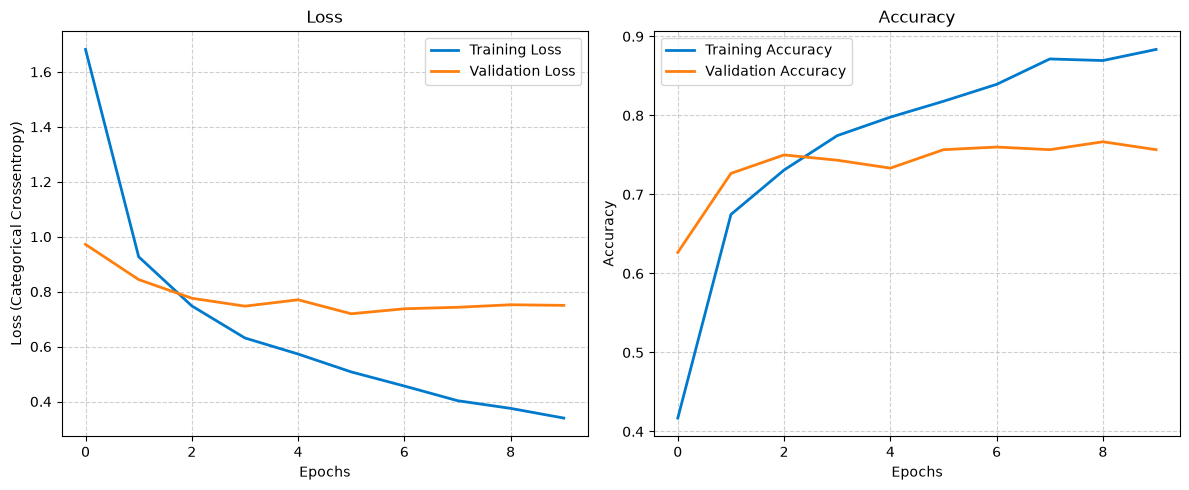

In [13]:
plot_loss_curve(history)

In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications.resnet50 import preprocess_input

def realtime_capture_and_predict(model):
    class_names = ['boots', 'flip_flops', 'loafers', 'sandals', 'sneakers', 'soccer_shoes']
    
    # 1. Open the webcam
    cap = cv2.VideoCapture(0)
    print("Opening camera... Look for a new window on your taskbar!")
    print("-> Press 'SPACEBAR' to capture the picture.")
    print("-> Press 'q' to cancel and close.")
    
    captured_frame = None
    
    while True:
        ret, frame = cap.read()
        if not ret:
            print("Error: Could not read from the camera.")
            break
            
        # 2. Show the live feed in a pop-up window
        cv2.imshow("Live Webcam (Press Space to Capture, Q to Quit)", frame)
        
        # 3. Listen for key presses (1ms delay)
        key = cv2.waitKey(1) & 0xFF
        
        if key == 32:  # 32 is the ASCII code for the Spacebar
            captured_frame = frame
            break
        elif key == ord('q'):  # If 'q' is pressed, exit
            break
            
    # 4. Release the camera and close the pop-up window
    cap.release()
    cv2.destroyAllWindows()
    
    # 5. Process the image IF we captured one
    if captured_frame is not None:
        # OpenCV uses BGR. Convert to standard RGB for displaying and processing
        frame_rgb = cv2.cvtColor(captured_frame, cv2.COLOR_BGR2RGB)
        
        # Show the captured shot inline in your Jupyter Notebook
        plt.figure(figsize=(5, 5))
        plt.imshow(frame_rgb)
        plt.axis("off")
        plt.title("Captured Shot")
        plt.show()
        
        # --- Prepare the in-memory image for ResNet ---
        
        # Resize to 224x224 (cv2 takes width, height)
        img_resized = cv2.resize(frame_rgb, (224, 224))
        
        # Convert to a mathematical array and add the batch dimension: (1, 224, 224, 3)
        img_array = np.expand_dims(img_resized, axis=0).astype('float32')
        
        # Apply ResNet's specific preprocessing (Zero-centering and BGR conversion)
        img_preprocessed = preprocess_input(img_array)
        
        # Ask the model to predict
        predictions = model.predict(img_preprocessed)
        predicted_index = np.argmax(predictions[0])
        confidence = np.max(predictions[0]) * 100
        predicted_label = class_names[predicted_index]
        
        print("-" * 30)
        print(f"Predicted Class : {predicted_label}")
        print(f"Confidence      : {confidence:.2f}%")
        print("-" * 30)
        
        return predicted_label, confidence
    else:
        print("Capture cancelled.")
        return None

# --- To use it ---
# realtime_capture_and_predict(model)

In [ ]:
realtime_capture_and_predict(model)


Opening camera... Look for a new window on your taskbar!
-> Press 'SPACEBAR' to capture the picture.
-> Press 'q' to cancel and close.


QFontDatabase: Cannot find font directory /home/love/coding/ml-project/.venv/lib/python3.11/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/love/coding/ml-project/.venv/lib/python3.11/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/love/coding/ml-project/.venv/lib/python3.11/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/love/coding/ml-project/.venv/lib/python3.11/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot fi

KeyboardInterrupt: 

: 